<a href="https://colab.research.google.com/github/baebsae3123/Titanic2025/blob/main/%EA%B3%B5%EC%9A%A9_%ED%83%80%EC%9D%B4%ED%83%80%EB%8B%89%ED%98%B8_%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터 상위 5개
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

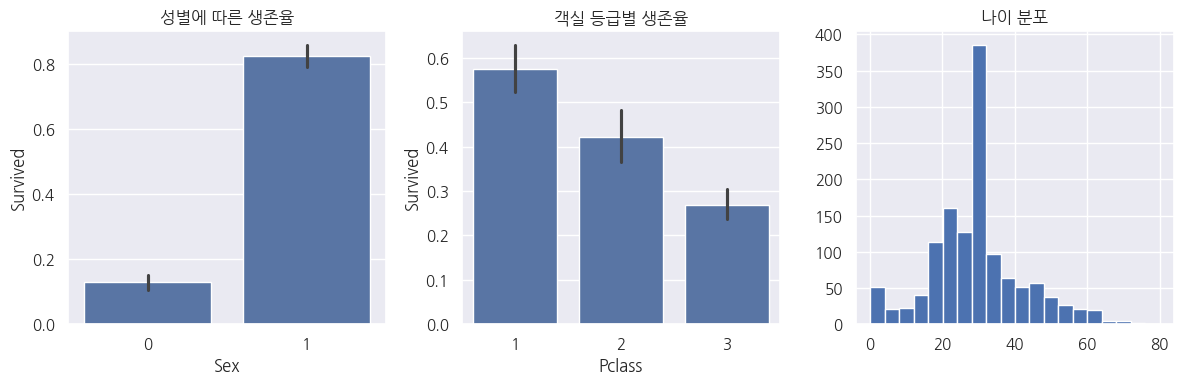


모델 정확도: 0.8625954198473282


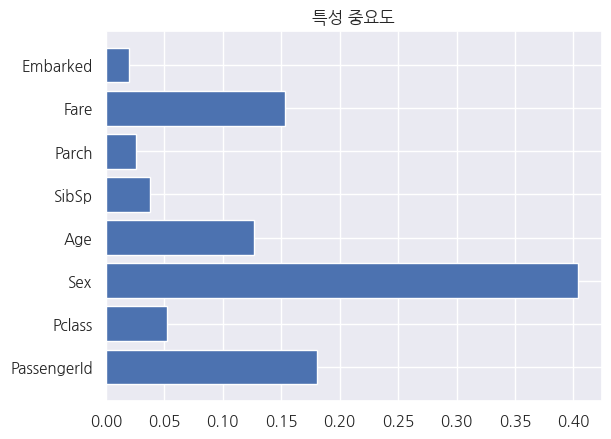

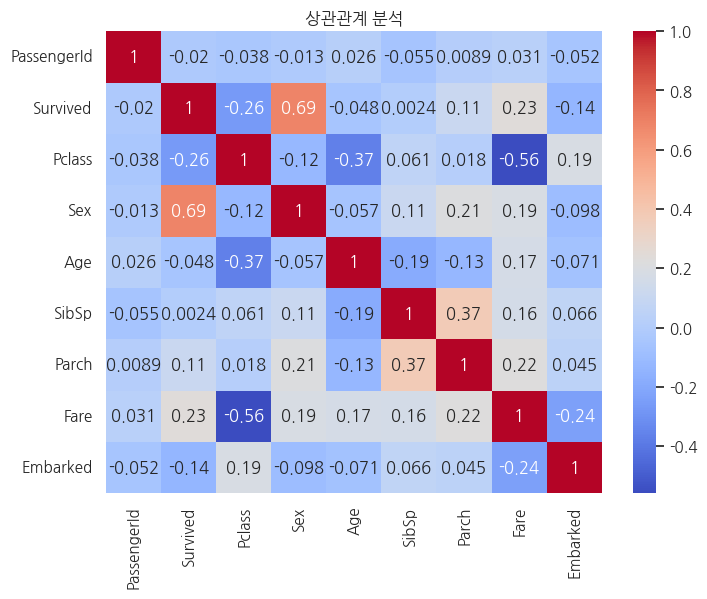

In [30]:
# 📌 1. 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

# 📌 2. 데이터 불러오기
df = pd.read_csv('titanic1309.csv')

# 📌 3. 데이터 확인
print("데이터 상위 5개")
print(df.head())

print("\n데이터 정보")
print(df.info())

# 📌 4. 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 📌 5. 불필요 컬럼 제거
df = df.drop(['Cabin', 'Name', 'Ticket'], axis=1, errors='ignore')

# 📌 6. 문자 → 숫자 변환
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# 📌 7. 시각화
plt.figure(figsize=(12,4))

# 성별 생존율
plt.subplot(1,3,1)
sns.barplot(x='Sex', y='Survived', data=df)
plt.title("성별에 따른 생존율")

# 객실 등급
plt.subplot(1,3,2)
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title("객실 등급별 생존율")

# 나이 분포
plt.subplot(1,3,3)
plt.hist(df['Age'], bins=20)
plt.title("나이 분포")

plt.tight_layout()
plt.show()

# 📌 8. 머신러닝
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n모델 정확도:", accuracy_score(y_test, y_pred))

# 📌 9. 중요도
importances = model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("특성 중요도")
plt.show()

# 📌 10. 히트맵
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("상관관계 분석")
plt.show()

In [28]:
!pip install koreanize-matplotlib

In [24]:
plt.rcParams['font.family'] = 'NanumGothic'
sns.set(font='NanumGothic')
plt.rc('font', family='NanumGothic')

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 👉 폰트 초기화 (중요)
plt.rcParams.update(plt.rcParamsDefault)
sns.set()